In [53]:
import numpy as np
import matplotlib.pyplot as plt
import os
from astropy.io import fits
import yaml


In [54]:
basedir = f'{os.environ["HOME"]}/projects/debrisdisk_freeform_fit_and_plot'

# Read in config file
default_param_file = "initialization_files/HR4796_i_camsci1_20230309_10.yaml"

param_file_loc = os.path.join(basedir, default_param_file)

# Read in config file
with open(param_file_loc, 'r') as file:
    config = yaml.safe_load(file)


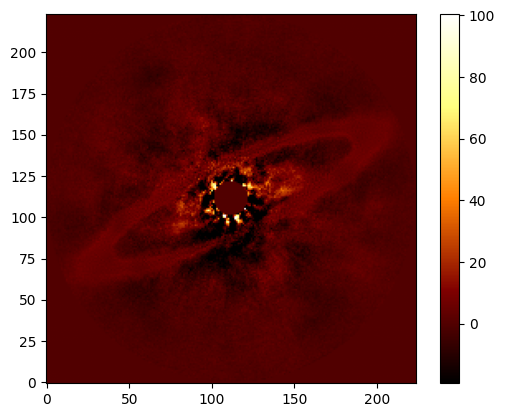

In [55]:
datadir = config["BAND_DIR"]
file_prefix = config["FILE_PREFIX"]
injected_dir = "/Users/jkueny/data/HR4796a_lco2023a_magao-x_20230309_10/raws_20230310T054736_s_lyot_stop/camsci1/injected_psflib"

klipdir = os.path.join(injected_dir, "klip_fm_files")
resultsdir = os.path.join(injected_dir, "results_freeform")

ex_opt_run = "opt_run_0035"

ex_results_loc = os.path.join(resultsdir, ex_opt_run)

residuals_loc = os.path.join(ex_results_loc, f"{file_prefix}_BestModel_Res.fits")
recovered_loc = os.path.join(ex_results_loc, f"{file_prefix}_BestModel.fits")

# diskless_image_loc = os.path.join(klipdir, f"{file_prefix}-klipped_counter_rotated.fits")

residuals_image = fits.getdata(residuals_loc)
recovered_model = fits.getdata(recovered_loc)
residuals_image[residuals_image != residuals_image] = 0.
recovered_model[recovered_model != recovered_model] = 0.

if residuals_image.ndim == 3:
    residuals_image = np.squeeze(residuals_image)

if recovered_model.ndim == 3:
    recovered_model = np.squeeze(recovered_model)

residuals_vmin = np.percentile(residuals_image, 1.01)
residuals_vmax = np.percentile(residuals_image, 99.99)

plt.imshow(
    residuals_image, origin="lower", cmap="afmhot",
    vmin=residuals_vmin, vmax=residuals_vmax,
    )
plt.colorbar()
plt.show()


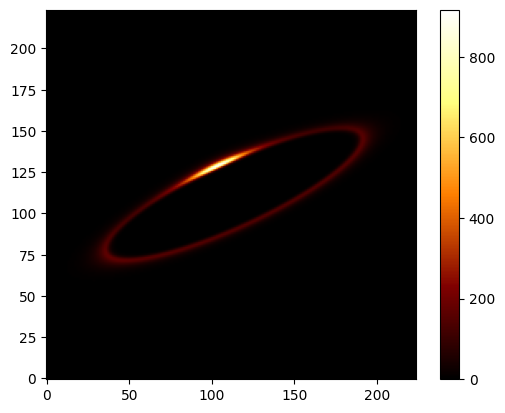

In [56]:
# Read in the initial model
injected_loc = os.path.join(klipdir, f"disk_model_to_inject.fits")

injected_model = fits.getdata(injected_loc)
injected_model[injected_model != injected_model] = 0.

if injected_model.ndim == 3:
    injected_model = np.squeeze(injected_model)

plt.imshow(injected_model, origin="lower", cmap="afmhot")
plt.colorbar()
plt.show()


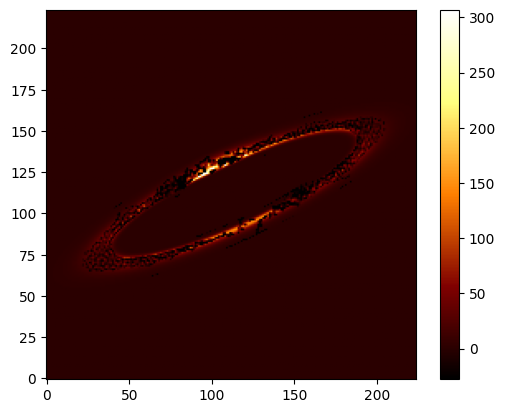

In [57]:
# Analyze the residuals

residuals = injected_model - recovered_model
residuals_vmin = np.percentile(residuals, 1.01)
residuals_vmax = np.percentile(residuals, 99.99)

plt.imshow(residuals, origin="lower", cmap="afmhot",
    vmin=residuals_vmin, vmax=residuals_vmax,
    )
plt.colorbar()
plt.show()

